# DBSCAN Anomaly Detection Experimentation

This notebook is used for Exploratory Data Analysis (EDA) and model training.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import joblib
import os

%matplotlib inline

## 1. Load Data


In [2]:
df = pd.read_csv('data/data.csv')
print("Data Preview:")
display(df.head())

Data Preview:


,user_id,daily_screen_time_hours,social_media_hours,study_work_hours,sleep_hours,tasks_completed,gaming_hours
0,1,8.22,1.94,4.07,4.29,11.01,3.19
1,2,8.69,1.89,3.93,4.00,11.37,3.25
2,3,8.71,2.35,3.87,4.00,11.35,3.62
3,4,8.24,1.79,3.73,4.00,10.79,3.08
4,5,8.11,1.14,3.29,4.00,10.34,2.53


## 2. Exploratory Data Analysis (EDA)

Check distributions and correlations.


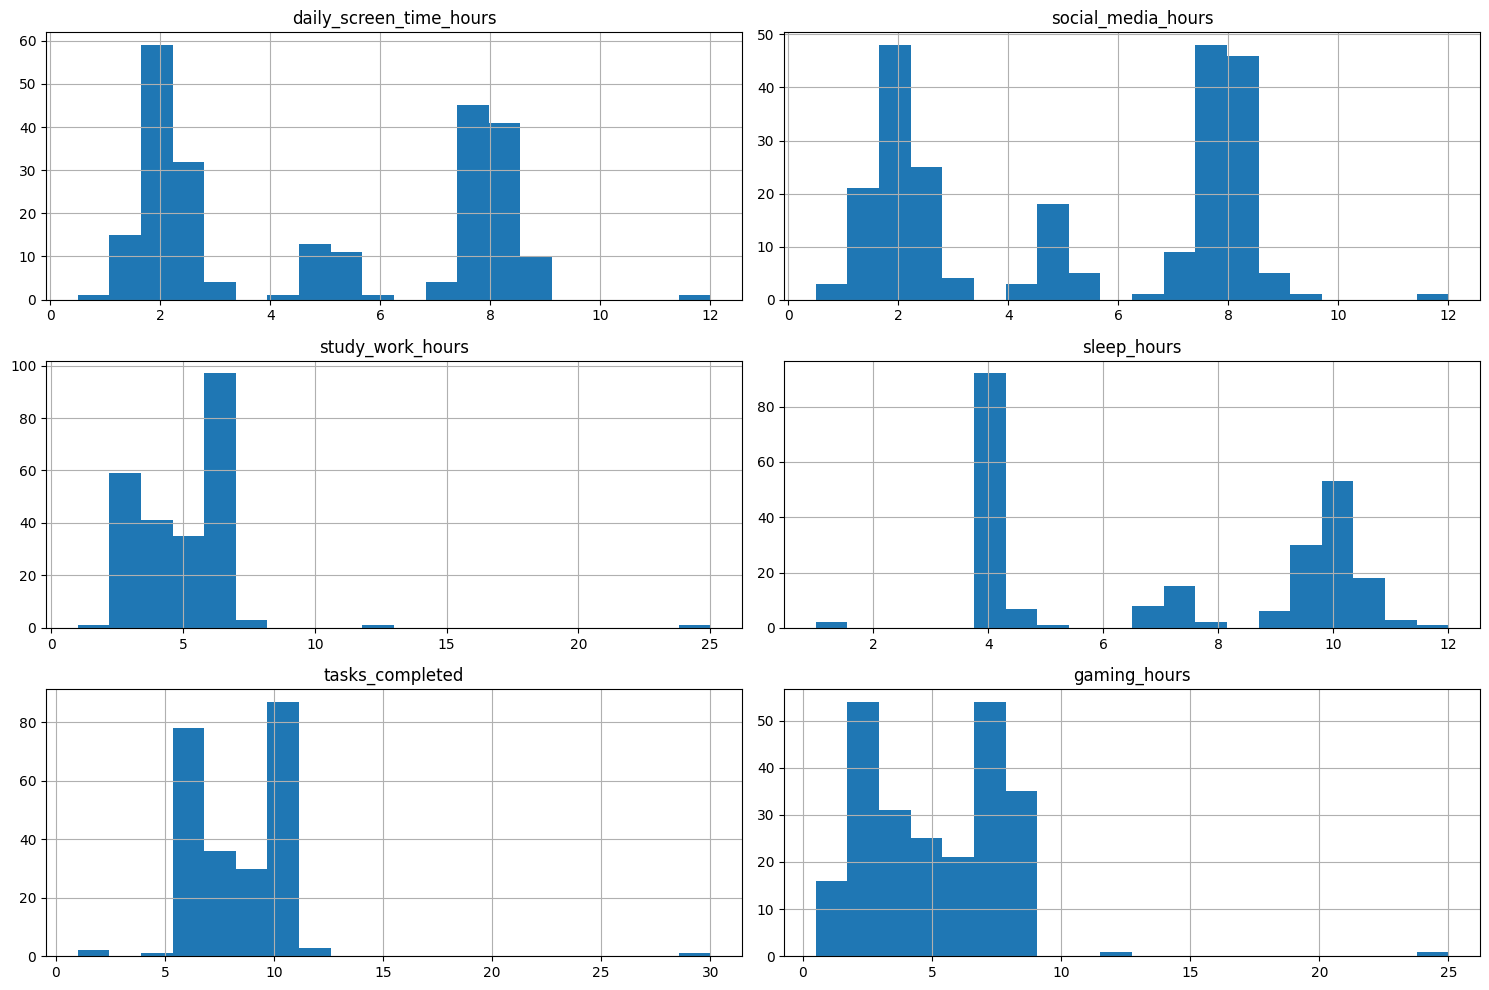

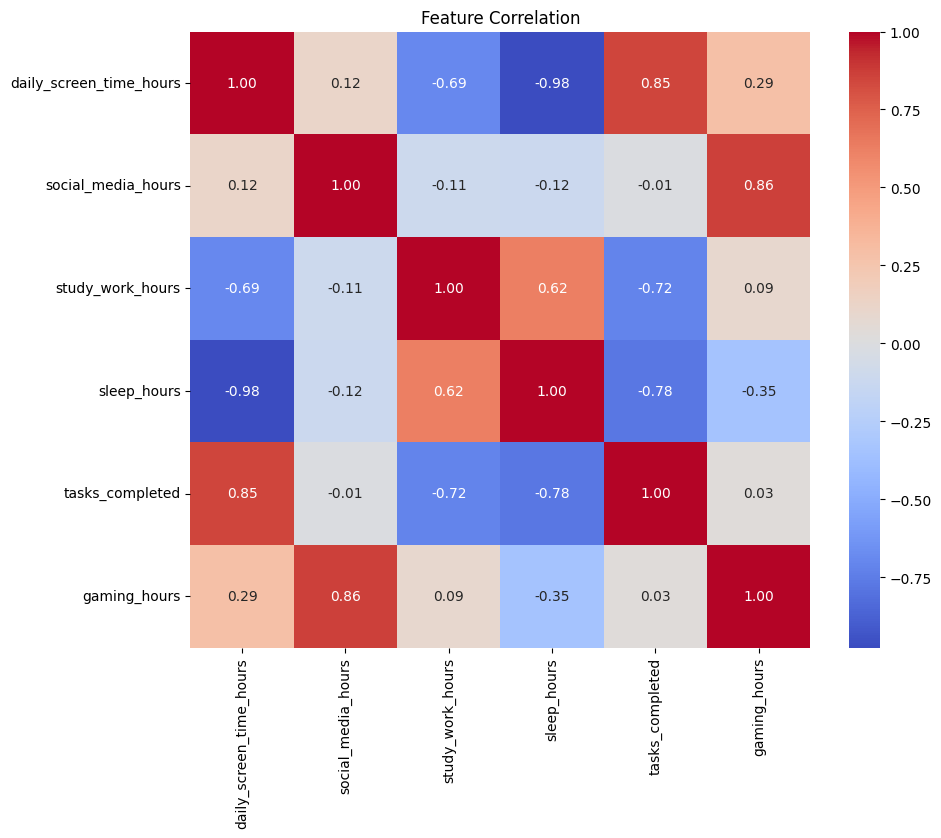

In [3]:
# Histograms
df.drop(columns=['user_id']).hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=['user_id']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation")
plt.show()

## 3. Model Training (DBSCAN)


In [4]:
features = df.drop(columns=['user_id'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# DBSCAN configuration
eps = 1.5
min_samples = 3
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(scaled_features)

df['segment'] = labels
df['is_anomaly'] = df['segment'] == -1

print(f"Found {sum(df['is_anomaly'])} anomalies.")
print("Segment counts:")
print(df['segment'].value_counts())

Found 3 anomalies.
Segment counts:
segment
 4    60
 3    60
 1    50
 0    40
 2    25
-1     3
Name: count, dtype: int64


## 4. Visualization of Clusters


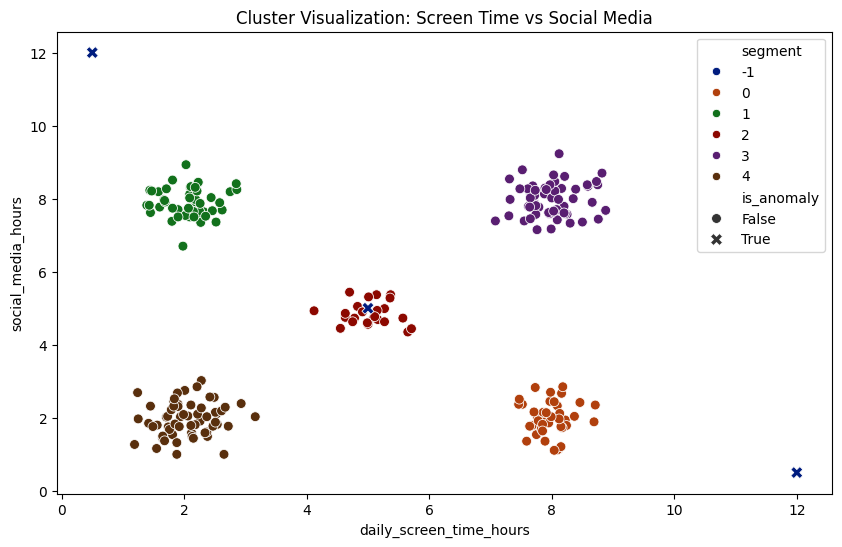

In [5]:
# Scatter plot of two features
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='daily_screen_time_hours',
    y='social_media_hours',
    hue='segment',
    palette='dark',
    style='is_anomaly',
    markers={True: 'X', False: 'o'},
    size='is_anomaly',
    sizes={True: 75, False: 50}
)
plt.legend(loc='best')
plt.title("Cluster Visualization: Screen Time vs Social Media")
plt.show()

## 5. Save Model and Results


In [6]:
os.makedirs('model', exist_ok=True)
df.to_csv('model/segments-anomalies.csv', index=False)

model_payload = {
    'scaler': scaler,
    'dbscan': dbscan,
    'feature_names': features.columns.tolist()
}
joblib.dump(model_payload, 'model/model.pkl')
print("Model and data saved successfully.")

Model and data saved successfully.
